In [1]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '.')

from DMeRates.DMeRate import DMeRate



In [2]:
# partial Fig 12 from https://arxiv.org/pdf/2306.14944

<>:64: SyntaxWarning: invalid escape sequence '\m'
<>:65: SyntaxWarning: invalid escape sequence '\m'
<>:64: SyntaxWarning: invalid escape sequence '\m'
<>:65: SyntaxWarning: invalid escape sequence '\m'
/var/folders/k8/_jhxw6sx2gj8wjzbhc789q540000gn/T/ipykernel_81399/2360479698.py:64: SyntaxWarning: invalid escape sequence '\m'
  Line2D([0], [0], color='gray', lw=2, ls='-', label='$F_{\mathrm{DM}} = 1$'),
/var/folders/k8/_jhxw6sx2gj8wjzbhc789q540000gn/T/ipykernel_81399/2360479698.py:65: SyntaxWarning: invalid escape sequence '\m'
  Line2D([0], [0], color='gray', lw=2, ls='--', label='$F_{\mathrm{DM}} \propto 1/q^2$')


CUDA/MPS GPU not found, performing calculations on cpu (if you are doing this on apple silicon you can change your device to mps if you'd like)
Using form factor calculated from file: /Users/ansh/Local/SENSEI/DarkMatterRates/tests/../DMeRates/../form_factors/QCDark/Si_final.hdf5
CUDA/MPS GPU not found, performing calculations on cpu (if you are doing this on apple silicon you can change your device to mps if you'd like)
Using form factor calculated from file: /Users/ansh/Local/SENSEI/DarkMatterRates/tests/../DMeRates/../form_factors/QCDark/Ge_final.hdf5


/Users/ansh/.pyenv/versions/3.12.2/lib/python3.12/site-packages/torch/__init__.py:1323: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/tensor/python_tensor.cpp:436.)
  _C._set_default_tensor_type(t)
/Users/ansh/.pyenv/versions/3.12.2/lib/python3.12/site-packages/torchquad/integration/simpson.py:76: UserWarning: N per dimension cannot be even due to necessary subdivisions. N per dim will now be changed to the next lower integer, i.e. 1250 -> 1249.
  warnings.warn(
/Users/ansh/.pyenv/versions/3.12.2/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, *

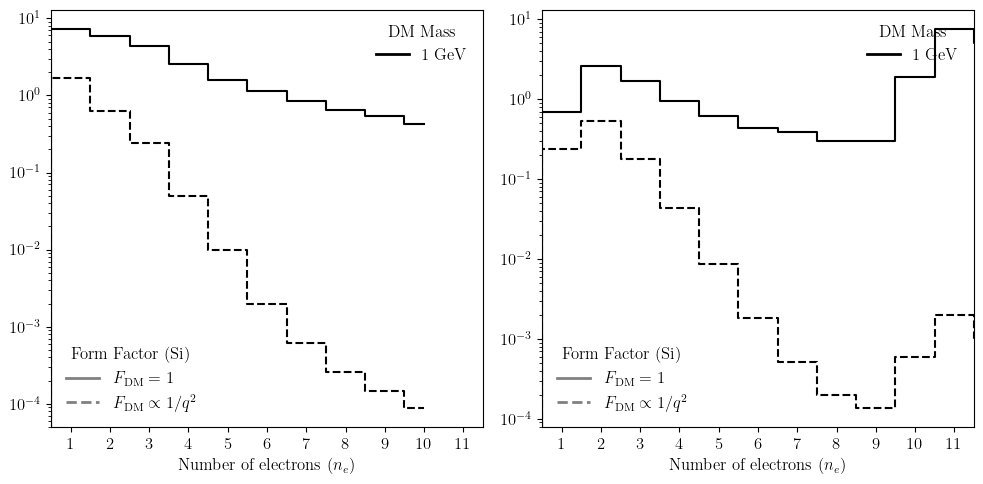

In [3]:
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.offsetbox import AnchoredText
from matplotlib.lines import Line2D  # Required for creating custom legend entries
import numpy as np
import numericalunits as nu

#Options
params = {'text.usetex' : True,
        'font.size' : 12,
        'font.family' : 'serif',
        'figure.autolayout': True
        }
plt.rcParams.update(params)
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['axes.labelsize']=12

# test_params 
mX = [1000]
sigmaE = 1e-39
halo_model = 'imb'
DoScreen = True
fig,axes =plt.subplots(1,2,figsize=(10,5))



# Plot the lines without assigning 'label' arguments inside the loop
for material in ['Si','Ge']:
    ax = axes[0] if material =='Si' else axes[1]
    ne = np.arange(11) if material == 'Si' else np.arange(15)
    qcdark = DMeRate(material, form_factor_type='qcdark')
    qcdark.update_crosssection(1e-39)
    # qedark.change_to_step()
    for FDMn in [0, 2]:
        ls = '-' if FDMn == 0 else '--'
        rates = qcdark.calculate_rates(mX_array=mX, halo_model=halo_model, FDMn=FDMn, ne=ne, DoScreen=True, integrate=True)

        rates = rates.cpu().numpy() * nu.kg * nu.year
        # for i in [0, 1]:
            # rates[:, i] = rates[:, i] / rates[1,i]

            
        # Use where='mid' so the flat part of the step is centered on the integer 'ne'
        ax.step(ne, rates[:, 0], color='black', ls=ls, where='mid')
        # ax.step(ne, rates[:, 1], color='black', ls=ls, where='mid')

    ax.set_yscale('log')
    # ax.set_ylim(1e-7, 4)

    # Create custom handles for the Mass legend (distinguished by Color)
    mass_lines = [
        # Line2D([0], [0], color='steelblue', lw=2, label='10 MeV'),
        Line2D([0], [0], color='black', lw=2, label='1 GeV')
    ]
    # Place the first legend and add it to the axes manually
    mass_legend = ax.legend(handles=mass_lines, loc='upper right', frameon=False, title='DM Mass')
    ax.add_artist(mass_legend) 

    # Create custom handles for the Form Factor legend (distinguished by Linestyle)
    fdmn_lines = [
        Line2D([0], [0], color='gray', lw=2, ls='-', label='$F_{\mathrm{DM}} = 1$'),
        Line2D([0], [0], color='gray', lw=2, ls='--', label='$F_{\mathrm{DM}} \propto 1/q^2$')
    ]
    # Place the second legend
    ax.legend(handles=fdmn_lines, loc='lower left', frameon=False, title='Form Factor (Si)')

    # Set limits to .5 intervals so the edge bins are fully visible, and set ticks to integers
    ax.set_xlim(0.5, 11.5)
    ax.set_xticks(np.arange(1, 12))
    ax.set_xlabel('Number of electrons ($n_e$)')

plt.show()
plt.close()
